In [1]:
import numpy as np
from numpy.polynomial.polynomial import polyval
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, PchipInterpolator


### Zad 1
#### Przygotowanie danych oraz zastosowanie Vermonda

In [2]:
years = np.array([i for i in range(1900,1981,10)])
population = np.array([76_212_168,92_228_496,106_021_496,123_202_624,132_164_569,151_325_798
                      ,179_323_175,203_302_031,226_542_199])
V_1 = np.vander(years,increasing = True)
V_2 = np.vander(years-1900,increasing = True)
V_3 = np.vander(years-1940,increasing = True)
V_4 = np.vander((years-1940)/40,increasing = True)

print(np.linalg.cond(V_1))
print(np.linalg.cond(V_2))
print(np.linalg.cond(V_3))
print(np.linalg.cond(V_4))

A = np.linalg.solve(V_4,population)

1.1393798408458244e+26
6110183760727540.0
9315536046807.896
1605.4437004786923


In [3]:
def horner(coeffs, x):
    w = 0
    for a in coeffs:
        w = w * x + a
    return w

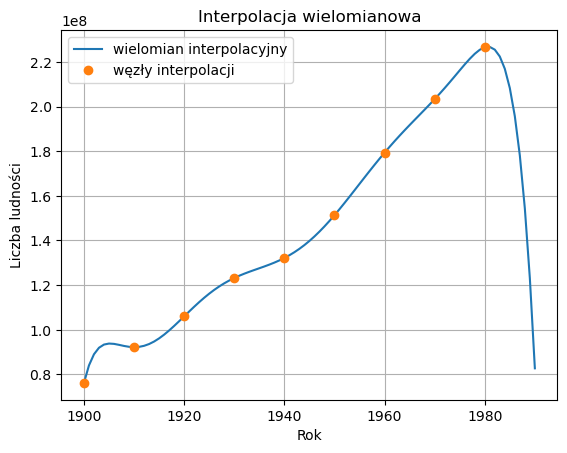

In [4]:

x = np.arange(1900, 1991, 1)
y = horner(A[::-1],(x-1940)/40)

plt.plot(x, y, label='wielomian interpolacyjny')
plt.plot(years, population, 'o', label='węzły interpolacji')

plt.xlabel('Rok')
plt.ylabel('Liczba ludności')
plt.title('Interpolacja wielomianowa')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
real_val = 248_709_873
val = horner(A[::-1],(1990-1940)/40)
err = np.abs(real_val-val)/real_val
print(err)

0.667292399767325


#### Lagrange

In [6]:
def lagrange(xs, ys, x):
    n = len(xs)
    wynik = 0

    for i in range(n):
        Li = 1
        for j in range(n):
            if i != j:
                Li *= (x - xs[j]) / (xs[i] - xs[j])
        wynik += ys[i] * Li

    return wynik

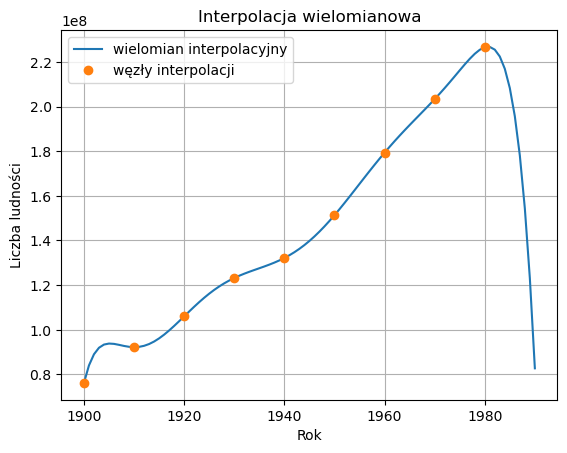

In [7]:

x = np.arange(1900, 1991, 1)
y = lagrange(years,population,x)

plt.plot(x, y, label='wielomian interpolacyjny')
plt.plot(years, population, 'o', label='węzły interpolacji')

plt.xlabel('Rok')
plt.ylabel('Liczba ludności')
plt.title('Interpolacja wielomianowa')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
real_val = 248_709_873
val = lagrange(years,population,1990)
err = np.abs(real_val-val)/real_val
print(err)

0.6672923997673309


#### Newton

In [9]:
def newton_coeffs(xs, ys):
    n = len(xs)
    a = ys.astype(float).copy()

    for j in range(1, n):
        for i in range(n - 1, j - 1, -1):
            a[i] = (a[i] - a[i - 1]) / (xs[i] - xs[i - j])

    return a

In [10]:
def newton_eval(xs, a, x):
    n = len(a)
    wynik = a[n - 1]
    for i in range(n - 2, -1, -1):
        wynik = wynik * (x - xs[i]) + a[i]
    return wynik

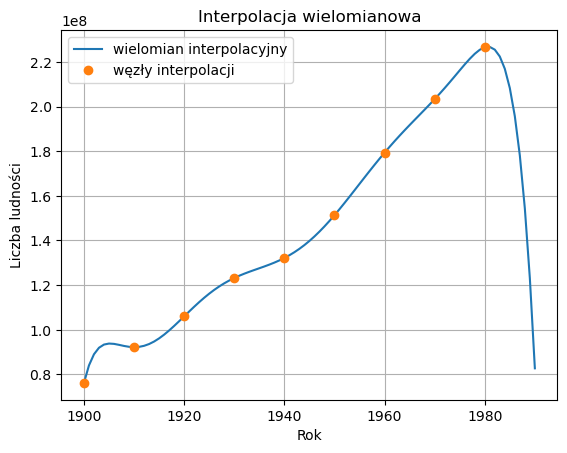

In [11]:
x = np.arange(1900, 1991, 1)
y = newton_eval(years,newton_coeffs(years,population),x)

plt.plot(x, y, label='wielomian interpolacyjny')
plt.plot(years, population, 'o', label='węzły interpolacji')

plt.xlabel('Rok')
plt.ylabel('Liczba ludności')
plt.title('Interpolacja wielomianowa')
plt.grid(True)
plt.legend()
plt.show()

In [12]:
real_val = 248_709_873
val = newton_eval(years,newton_coeffs(years,population),1990)
err = np.abs(real_val-val)/real_val
print(err)

0.667292399767335


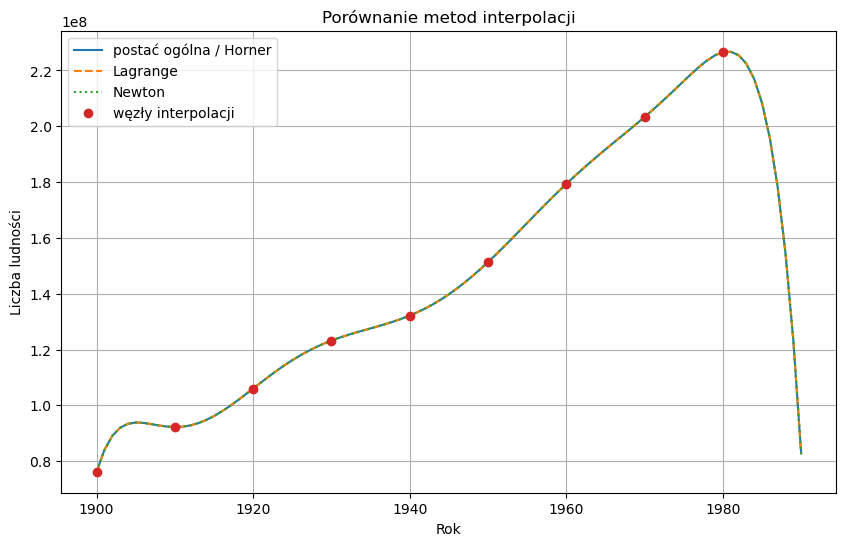

In [13]:
x = np.arange(1900, 1991, 1)

# wielomian z bazy najlepiej uwarunkowanej
y_horner = horner(A[::-1], (x - 1940) / 40)

# wielomian Lagrange’a
y_lagrange = lagrange(years, population, x)

# wielomian Newtona
a_newton = newton_coeffs(years, population)
y_newton = newton_eval(years, a_newton, x)

plt.figure(figsize=(10, 6))

plt.plot(x, y_horner, label='postać ogólna / Horner')
plt.plot(x, y_lagrange, '--', label='Lagrange')
plt.plot(x, y_newton, ':', label='Newton')
plt.plot(years, population, 'o', label='węzły interpolacji')

plt.xlabel('Rok')
plt.ylabel('Liczba ludności')
plt.title('Porównanie metod interpolacji')
plt.grid(True)
plt.legend()
plt.show()

#### Dane zaaokrąglone

In [14]:
pr = np.round(population,-6)

A_r = np.linalg.solve(V_4,pr)
print(A)
print(A_r)

[ 1.32164569e+08  4.61307328e+07  1.02716380e+08  1.82527746e+08
 -3.74615947e+08 -3.42669972e+08  6.06294282e+08  1.89176509e+08
 -3.15182101e+08]
[ 1.32000000e+08  4.59571429e+07  1.00141270e+08  1.81111111e+08
 -3.56755556e+08 -3.38488889e+08  5.70311111e+08  1.86920635e+08
 -2.94196825e+08]


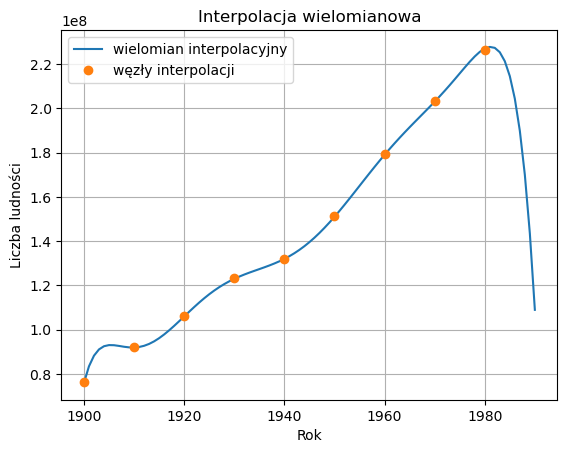

In [15]:

x = np.arange(1900, 1991, 1)
y = horner(A_r[::-1],(x-1940)/40)

plt.plot(x, y, label='wielomian interpolacyjny')
plt.plot(years, population, 'o', label='węzły interpolacji')

plt.xlabel('Rok')
plt.ylabel('Liczba ludności')
plt.title('Interpolacja wielomianowa')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
real_val = 248_709_873
val = horner(A_r[::-1],(1990-1940)/40)
err = np.abs(real_val-val)/real_val
print(err)
print(val)

0.5617383472347983
109000000.0000034


### zad 2

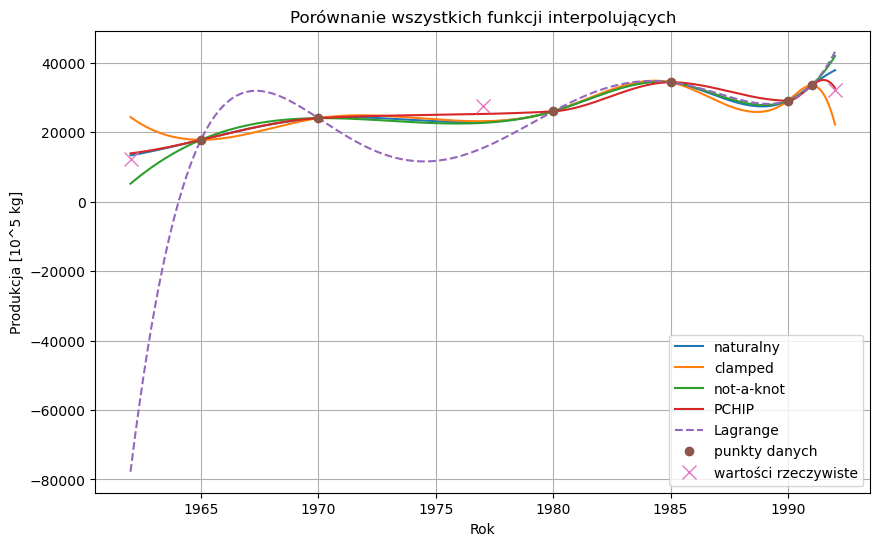

In [17]:
years = np.array([1965, 1970, 1980, 1985, 1990, 1991], dtype=float)
production = np.array([17769, 24001, 25961, 34336, 29036, 33417], dtype=float)

check_years = np.array([1962, 1977, 1992], dtype=float)
true_values = np.array([12380, 27403, 32059], dtype=float)

cs_natural = CubicSpline(years, production, bc_type='natural')
cs_clamped = CubicSpline(years, production, bc_type='clamped')
cs_notaknot = CubicSpline(years, production, bc_type='not-a-knot')
pchip = PchipInterpolator(years, production)

x = np.linspace(1962, 1992, 500)
y_lagrange = lagrange(years, production, x)

plt.figure(figsize=(10, 6))
plt.plot(x, cs_natural(x), label='naturalny')
plt.plot(x, cs_clamped(x), label='clamped')
plt.plot(x, cs_notaknot(x), label='not-a-knot')
plt.plot(x, pchip(x), label='PCHIP')
plt.plot(x, y_lagrange, '--', label='Lagrange')
plt.plot(years, production, 'o', label='punkty danych')
plt.plot(check_years, true_values, 'x', markersize=10, label='wartości rzeczywiste')

plt.xlabel('Rok')
plt.ylabel('Produkcja [10^5 kg]')
plt.title('Porównanie wszystkich funkcji interpolujących')
plt.grid(True)
plt.legend()
plt.show()

In [18]:
methods = {
    "naturalny": cs_natural(check_years),
    "clamped": cs_clamped(check_years),
    "not-a-knot": cs_notaknot(check_years),
    "PCHIP": pchip(check_years),
    "lagrange": lagrange(years, production, check_years)
}

for name, values in methods.items():
    print(name)
    for year, pred, true in zip(check_years, values, true_values):
        error = abs(pred - true) / abs(true) * 100
        print(f"  {int(year)}: wynik = {pred:.2f}, prawdziwa = {true:.2f}, błąd względny = {error:.2f}%")
    print()

naturalny
  1962: wynik = 13285.30, prawdziwa = 12380.00, błąd względny = 7.31%
  1977: wynik = 22934.24, prawdziwa = 27403.00, błąd względny = 16.31%
  1992: wynik = 37798.00, prawdziwa = 32059.00, błąd względny = 17.90%

clamped
  1962: wynik = 24313.02, prawdziwa = 12380.00, błąd względny = 96.39%
  1977: wynik = 23125.97, prawdziwa = 27403.00, błąd względny = 15.61%
  1992: wynik = 22165.79, prawdziwa = 32059.00, błąd względny = 30.86%

not-a-knot
  1962: wynik = 5146.10, prawdziwa = 12380.00, błąd względny = 58.43%
  1977: wynik = 22641.77, prawdziwa = 27403.00, błąd względny = 17.37%
  1992: wynik = 41894.36, prawdziwa = 32059.00, błąd względny = 30.68%

PCHIP
  1962: wynik = 13868.97, prawdziwa = 12380.00, błąd względny = 12.03%
  1977: wynik = 25204.28, prawdziwa = 27403.00, błąd względny = 8.02%
  1992: wynik = 32663.33, prawdziwa = 32059.00, błąd względny = 1.89%

lagrange
  1962: wynik = -77765.36, prawdziwa = 12380.00, błąd względny = 728.15%
  1977: wynik = 15404.96, prawd